Found 1800 files belonging to 5 classes.
Using 1440 files for training.
Found 1800 files belonging to 5 classes.
Using 360 files for validation.
Found 225 files belonging to 5 classes.
Classes: ['Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

None
Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.2028 - loss: 1.6723 - val_accuracy: 0.1889 - val_loss: 1.6205
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.2049 - loss: 1.6261 - val_accuracy: 0.1944 - val_loss: 1.6292
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.2014 - loss: 1.6255 - val_accuracy: 0.1944 - val_loss: 1.6193
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.2174 - loss: 1.6139 - val_accuracy: 0.1944 - val_loss: 1.6099
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.1979 - loss: 1.6104 - val_accuracy: 0.1944 - val_loss: 1.6098
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.1965 - loss: 1.6101 - val_accuracy: 0.1944 - val_loss: 1.6102
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.1972 - loss: 1.6094 - val_accuracy: 0.1750 - val_loss: 1.6103
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.2000 - loss: 1.6100 - val_accuracy: 0.1750 - v

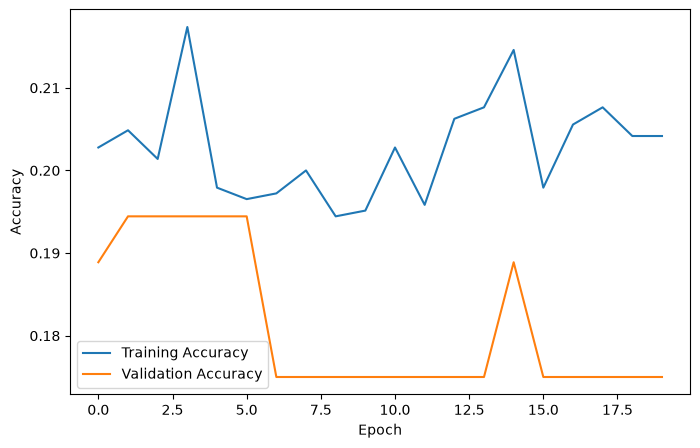

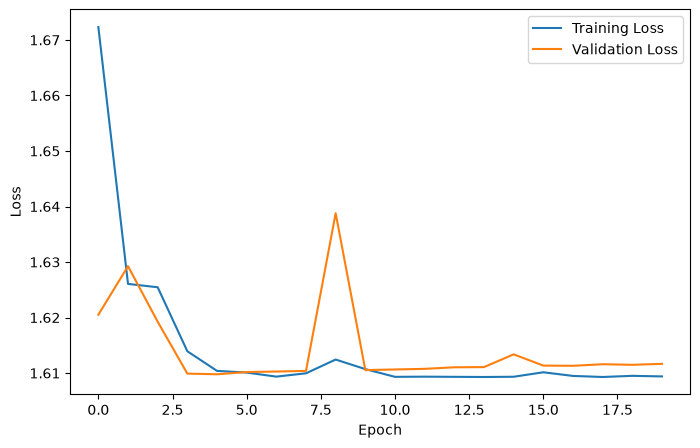


Model Saved Successfully!


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, Model

# -----------------------------
# Dataset Paths
# -----------------------------
train_dir = r"C:\Users\prave\OneDrive\Desktop\jupyter notebook 333\Skin Type Identification Research\train"
test_dir = r"C:\Users\prave\OneDrive\Desktop\jupyter notebook 333\Skin Type Identification Research\test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

# -----------------------------
# Load Dataset
# -----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# -----------------------------
# Class Names
# -----------------------------
class_names = train_ds.class_names
print("Classes:", class_names)

# -----------------------------
# Normalize Dataset
# -----------------------------
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y:(normalization_layer(x),y))
val_ds = val_ds.map(lambda x,y:(normalization_layer(x),y))
test_ds = test_ds.map(lambda x,y:(normalization_layer(x),y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# -----------------------------
# Data Augmentation
# -----------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# -----------------------------
# Load EfficientNetB0
# -----------------------------
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

# -----------------------------
# Build Model
# -----------------------------
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = Model(inputs, outputs)

# -----------------------------
# Compile
# -----------------------------
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(model.summary())

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# -----------------------------
# Evaluate
# -----------------------------
loss, accuracy = model.evaluate(test_ds)

print("\nTest Accuracy:", accuracy*100,"%")

# -----------------------------
# Accuracy Graph
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -----------------------------
# Loss Graph
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label="Training Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -----------------------------
# Save Model
# -----------------------------
model.save("skin_type_classifier.keras")

print("\nModel Saved Successfully!")